In [ ]:
import json
import os
from collections import Counter
import matplotlib.pyplot as plt

# === Config ===
annotations_path = '/kaggle/input/vehide-dataset-automatic-vehicle-damage-detection/0Train_via_annos.json'
classes = ['mat_bo_phan', 'rach', 'mop_lom', 'tray_son', 'thung', 'vo_kinh', 'be_den']
class_to_idx = {name: i for i, name in enumerate(classes)}

# === Step 1: Load Annotations and Count ===
with open(annotations_path) as f:
    data = json.load(f)

counter = Counter()
total_images = 0

for entry in data.values():
    total_images += 1
    counted = set()
    for region in entry.get("regions", []):
        cls = region.get("class")
        if cls in class_to_idx and cls not in counted:
            counter[cls] += 1
            counted.add(cls)

# === Step 2: Display Counts ===
print("📊 Class Distribution:")
for cls in classes:
    print(f"{cls:<12} : {counter[cls]} images")

# === Step 3: Compute Inverse Frequency Weights (optional) ===
max_count = max(counter.values())
weights = {cls: round(max_count / count, 2) if count > 0 else 0 for cls, count in counter.items()}

print("\n⚖️  Suggested Class Weights (inverse freq):")
for cls in classes:
    print(f"{cls:<12} : {weights[cls]}")

# === Step 4: Plot Bar Chart ===
plt.figure(figsize=(10, 4))
plt.bar(counter.keys(), counter.values(), color='skyblue')
plt.title("Class Distribution in Training Data")
plt.xlabel("Class")
plt.ylabel("Image Count")
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

In [ ]:
# Needed::

import os
import json
import torch
import random
import numpy as np
import torchvision
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from PIL import Image, ImageFile
import matplotlib.patches as patches
from torchvision import transforms, models
# from torchvision.references.detection import engine
# from engine import train_one_epoch, evaluate
from torchvision.datasets import CocoDetection
from torch.utils.data import Dataset, DataLoader
from torchvision.models.detection import FasterRCNN
from torchvision.transforms import v2 as transforms
from torchvision.models.detection.rpn import AnchorGenerator
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

In [ ]:
import os, json, random
import numpy as np
from PIL import Image, ImageFile
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import classification_report
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

ImageFile.LOAD_TRUNCATED_IMAGES = True

# Device setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Configuration
CLASSES = ['mat_bo_phan', 'rach', 'mop_lom', 'tray_son', 'thung', 'vo_kinh', 'be_den']
CLASS_TO_IDX = {name: i for i, name in enumerate(CLASSES)}
BATCH_SIZE = 32
LR = 0.0001
EPOCHS = 10

In [ ]:
class VehicleDamageDataset(Dataset):
    def __init__(self, img_dir, annotations_file, transform=None):
        self.img_dir = img_dir
        self.transform = transform
        with open(annotations_file) as f:
            self.annotations = json.load(f)
        self.valid_images = [img for img in self.annotations if os.path.exists(os.path.join(img_dir, img))]

    def __len__(self):
        return len(self.valid_images)

    def __getitem__(self, idx):
        img_name = self.valid_images[idx]
        img_path = os.path.join(self.img_dir, img_name)
        try:
            image = Image.open(img_path).convert('RGB')
        except:
            return self[random.randint(0, len(self)-1)]

        target = torch.zeros(len(CLASSES), dtype=torch.float32)
        for region in self.annotations[img_name].get('regions', []):
            class_name = region['class']
            if class_name in CLASS_TO_IDX:
                target[CLASS_TO_IDX[class_name]] = 1.0

        if self.transform:
            image = self.transform(image)
        return image, target

In [ ]:
transform = transforms.Compose([
    transforms.Resize((512, 512)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_data = VehicleDamageDataset(
    '/kaggle/input/vehide-dataset-automatic-vehicle-damage-detection/image/image',
    '/kaggle/input/vehide-dataset-automatic-vehicle-damage-detection/0Train_via_annos.json',
    transform
)

val_data = VehicleDamageDataset(
    '/kaggle/input/vehide-dataset-automatic-vehicle-damage-detection/validation/validation',
    '/kaggle/input/vehide-dataset-automatic-vehicle-damage-detection/0Val_via_annos.json',
    transform
)

train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)
val_loader = DataLoader(val_data, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)

In [ ]:
class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, reduction='mean'):
        super().__init__()
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        BCE_loss = nn.functional.binary_cross_entropy_with_logits(inputs, targets, reduction='none')
        pt = torch.exp(-BCE_loss)
        loss = (1 - pt) ** self.gamma * BCE_loss
        return loss.mean() if self.reduction == 'mean' else loss.sum()

In [ ]:
##### class DamageNet(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.base = models.resnet50(weights='DEFAULT')
        in_features = self.base.fc.in_features
        self.base.fc = nn.Sequential(
            nn.Linear(in_features, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        return self.base(x)

model = DamageNet(len(CLASSES)).to(device)

In [ ]:
##### criterion = FocalLoss()
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=2)

best_val_loss = float('inf')

for epoch in range(EPOCHS):
    model.train()
    train_loss = 0.0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    model.eval()
    val_loss = 0.0
    correct = 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            val_loss += criterion(outputs, labels).item()
            preds = (torch.sigmoid(outputs) > 0.5).int()

            all_preds.append(preds.cpu().numpy())
            all_labels.append(labels.cpu().numpy())
            correct += (preds == labels.bool()).all(dim=1).sum().item()

    all_preds = np.vstack(all_preds)
    all_labels = np.vstack(all_labels)

    train_loss /= len(train_loader)
    val_loss /= len(val_loader)
    val_acc = correct / len(val_data)
    scheduler.step(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save({
            'model_state_dict': model.state_dict(),
            'class_to_idx': CLASS_TO_IDX,
            'optimizer_state_dict': optimizer.state_dict(),
            'val_loss': val_loss,
        }, '/kaggle/working/best_damage_model.pth')

    print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")
    print("\n--- Classification Report ---")
    print(classification_report(all_labels, all_preds, target_names=CLASSES, zero_division=0))

print("Training complete!")

In [ ]:
# Needed::

import torch
import torch.nn as nn
from torchvision import transforms, models
from PIL import Image
import os
import matplotlib.pyplot as plt

# --- Configuration ---
CLASSES = ['mat_bo_phan', 'rach', 'mop_lom', 'tray_son', 'thung', 'vo_kinh', 'be_den']
MODEL_PATH = '/kaggle/working/best_damage_model.pth'
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# --- Model Definition (Must match training architecture) ---
class DamageNet(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.base = models.resnet50(weights=None)  # Weights will be loaded from state_dict
        in_features = self.base.fc.in_features
        self.base.fc = nn.Sequential(
            nn.Linear(in_features, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes)
        )
        
    def forward(self, x):
        return self.base(x)

def predict_test_images(test_dir, transform, threshold=0.5):
    # Load model with proper architecture
    model = DamageNet(len(CLASSES)).to(device)
    
    # Load checkpoint with weights_only=True for security
    # checkpoint = torch.load(MODEL_PATH, map_location=device, weights_only=True)
    checkpoint = torch.load(MODEL_PATH, map_location=device) #For TPU
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()
    
    # Get class mapping
    idx_to_class = {v: k for k, v in checkpoint['class_to_idx'].items()}
    
    # Process images
    image_files = [f for f in os.listdir(test_dir) 
                 if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    
    for img_file in sorted(image_files):
        img_path = os.path.join(test_dir, img_file)
        try:
            # Load and process image
            img = Image.open(img_path).convert('RGB')
            img_tensor = transform(img).unsqueeze(0).to(device)
            
            # Predict
            with torch.no_grad():
                outputs = model(img_tensor)
                probs = torch.sigmoid(outputs).cpu().numpy().flatten()
            
            # Get predictions
            predictions = [(idx_to_class[i], float(p)) 
                         for i, p in enumerate(probs) if p > threshold]
            
            # Visualization
            plt.figure(figsize=(10, 6))
            plt.imshow(img)
            plt.axis('off')
            
            # Prepare annotation text
            if predictions:
                text = "DETECTED DAMAGE:\n" + "\n".join(
                    [f"→ {name.upper()}: {prob:.1%}" for name, prob in predictions])
            else:
                text = "No damage detected"
            
            # Add annotation
            plt.text(
                15, 15, text,
                fontsize=12,
                bbox=dict(
                    facecolor='white',
                    alpha=0.9,
                    edgecolor='red',
                    boxstyle='round,pad=0.5'
                ),
                color='black'
            )
            plt.title(f"Analysis: {img_file}", pad=20)
            plt.tight_layout()
            plt.show()
            
            # Console report
            print("\n" + "="*60)
            print(f"IMAGE: {img_file}")
            if predictions:
                print("DAMAGE FOUND:")
                for name, prob in predictions:
                    print(f"- {name.upper()}: {prob:.1%} confidence")
            else:
                print("STATUS: No significant damage detected")
            print("="*60)
            
        except Exception as e:
            print(f"\n⚠️ Error processing {img_file}: {str(e)}")
            continue

# Define transform (must match training transform)
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Usage
predict_test_images('/kaggle/input/predictions/', transform, threshold=0.5)

#### DamageNet with Resnet50 including the no_damage class.

In [1]:
import os
import shutil
import random

source_dir = '/kaggle/input/stanford-cars-dataset/cars_train/cars_train'  # or wherever your data is
target_dir = '/kaggle/working/no_damage_images'
os.makedirs(target_dir, exist_ok=True)

sample_size = 2500
all_images = []

for subdir, _, files in os.walk(source_dir):
    
    for file in files:
        if file.endswith('.jpg'):
            all_images.append(os.path.join(subdir, file))

sampled = random.sample(all_images, sample_size)

for i, path in enumerate(sampled):
    shutil.copy(path, os.path.join(target_dir, f'clean_{i:04d}.jpg'))

In [2]:
import os
import json
import random
from datetime import datetime

# === CONFIG ===
image_dir = '/kaggle/working/no_damage_images'  # folder with clean images
output_dir = '/kaggle/working/no_damage_annos'
train_split = 0.8  # 80% for training, 20% for validation

os.makedirs(output_dir, exist_ok=True)

# === Get all image filenames ===
image_filenames = [f for f in os.listdir(image_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
random.shuffle(image_filenames)

# === Split into train and val ===
split_idx = int(len(image_filenames) * train_split)
train_imgs = image_filenames[:split_idx]
val_imgs = image_filenames[split_idx:]

def make_via_dict(img_list):
    data = {}
    for fname in img_list:
        data[fname] = {
            "filename": fname,
            "size": -1,  # optional
            "regions": [],  # no damage = no annotation regions
            "file_attributes": {"class": "no_damage"}
        }
    return data

# === Generate VIA-style JSONs ===
train_json = make_via_dict(train_imgs)
val_json = make_via_dict(val_imgs)

# === Save to disk ===
with open(os.path.join(output_dir, '0Train_no_damage_via_annos.json'), 'w') as f:
    json.dump(train_json, f)

with open(os.path.join(output_dir, '0Val_no_damage_via_annos.json'), 'w') as f:
    json.dump(val_json, f)

print(f"✅ Generated VIA annotations for {len(train_imgs)} train and {len(val_imgs)} val images")

✅ Generated VIA annotations for 1200 train and 300 val images


In [3]:
# === IMPORTS ===
import os, json, random
import numpy as np
from PIL import Image, ImageFile
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from sklearn.metrics import classification_report

ImageFile.LOAD_TRUNCATED_IMAGES = True

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# === DATASET ===
class VehicleDamageDataset(torch.utils.data.Dataset):
    def __init__(self, image_dirs, annotations_file, transform=None):
        """
        image_dirs: list of folder paths to look for images
        """
        self.image_dirs = image_dirs if isinstance(image_dirs, list) else [image_dirs]
        self.transform = transform

        with open(annotations_file) as f:
            self.annotations = json.load(f)

        self.valid_images = []
        for img_name in self.annotations:
            if self._find_image_path(img_name):
                self.valid_images.append(img_name)

    def _find_image_path(self, img_name):
        for dir in self.image_dirs:
            path = os.path.join(dir, img_name)
            if os.path.exists(path):
                return path
        return None

    def __len__(self):
        return len(self.valid_images)

    def __getitem__(self, idx):
        img_name = self.valid_images[idx]
        img_path = self._find_image_path(img_name)

        if img_path is None:
            return self[random.randint(0, len(self)-1)]

        image = Image.open(img_path).convert('RGB')

        target = torch.zeros(len(CLASSES), dtype=torch.float32)
        regions = self.annotations[img_name].get("regions", [])

        if not regions:
            target[CLASS_TO_IDX["no_damage"]] = 1.0
        else:
            for region in regions:
                cls = region.get("class")
                if cls in CLASS_TO_IDX:
                    target[CLASS_TO_IDX[cls]] = 1.0

        if self.transform:
            image = self.transform(image)

        return image, target

Using device: cuda


In [6]:
# === CONFIG ===
CLASSES = ['no_damage', 'mat_bo_phan', 'rach', 'mop_lom', 'tray_son', 'thung', 'vo_kinh', 'be_den']
CLASS_TO_IDX = {name: i for i, name in enumerate(CLASSES)}
BATCH_SIZE = 32
LR = 0.0001
EPOCHS = 10

In [4]:
import json

def merge_jsons(json1_path, json2_path, output_path):
    with open(json1_path) as f1, open(json2_path) as f2:
        data1 = json.load(f1)
        data2 = json.load(f2)

    merged = {**data1, **data2}

    with open(output_path, 'w') as f:
        json.dump(merged, f)

# Paths
merge_jsons(
    '/kaggle/input/vehide-dataset-automatic-vehicle-damage-detection/0Train_via_annos.json',
    '/kaggle/working/no_damage_annos/0Train_no_damage_via_annos.json',
    '/kaggle/working/0Train_combined.json'
)

merge_jsons(
    '/kaggle/input/vehide-dataset-automatic-vehicle-damage-detection/0Val_via_annos.json',
    '/kaggle/working/no_damage_annos/0Val_no_damage_via_annos.json',
    '/kaggle/working/0Val_combined.json'
)

In [7]:
# === TRANSFORMS ===
transform = transforms.Compose([
    transforms.Resize((300, 300)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(0.2, 0.2, 0.2),
    transforms.ToTensor(),
    transforms.RandomAdjustSharpness(1.5, p=0.5),
    transforms.RandomAutocontrast(p=0.3),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

train_data = VehicleDamageDataset(
    image_dirs=[
        '/kaggle/input/vehide-dataset-automatic-vehicle-damage-detection/image/image',
        '/kaggle/working/no_damage_images'
    ],
    annotations_file='/kaggle/working/0Train_combined.json',
    transform=transform
)

val_data = VehicleDamageDataset(
    image_dirs=[
        '/kaggle/input/vehide-dataset-automatic-vehicle-damage-detection/validation/validation',
        '/kaggle/working/no_damage_images'  # only if val images are also here
    ],
    annotations_file='/kaggle/working/0Val_combined.json',
    transform=transform
)

train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)
val_loader = DataLoader(val_data, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)

In [8]:
class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, reduction='mean'):
        super().__init__()
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        BCE_loss = nn.functional.binary_cross_entropy_with_logits(inputs, targets, reduction='none')
        pt = torch.exp(-BCE_loss)  # confidence
        focal_loss = (1 - pt) ** self.gamma * BCE_loss
        return focal_loss.mean() if self.reduction == 'mean' else focal_loss.sum()

In [9]:
from torchvision.models import (
    efficientnet_b0,
    efficientnet_b1,
    efficientnet_b2,
    efficientnet_b3,
    efficientnet_b4,
    efficientnet_b5,
    efficientnet_b6,
    efficientnet_b7,
)

In [10]:
# === MODEL ===
class DamageNet(nn.Module):
    def __init__(self, num_classes):
        super(DamageNet, self).__init__()
        self.base = efficientnet_b2(weights='DEFAULT')  # Load pretrained weights

        # Replace the classifier head
        in_features = self.base.classifier[1].in_features
        self.base.classifier = nn.Sequential(
            nn.Linear(in_features, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes)
        )
    def forward(self, x):
        return self.base(x)

model = DamageNet(len(CLASSES)).to(device)

# === LOSS & OPTIMIZER ===
criterion = FocalLoss(gamma=2.0)
# criterion = nn.BCEWithLogitsLoss()
# optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9, weight_decay=1e-4, nesterov=True)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=5)

# === TRAINING ===
best_val_loss = float('inf')

for epoch in range(EPOCHS):
    model.train()
    train_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    model.eval()
    val_loss = 0.0
    correct = 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            val_loss += criterion(outputs, labels).item()

            preds = (torch.sigmoid(outputs) > 0.5).int()
            all_preds.append(preds.cpu().numpy())
            all_labels.append(labels.cpu().numpy())
            correct += (preds == labels.bool()).all(dim=1).sum().item()

    all_preds = np.vstack(all_preds)
    all_labels = np.vstack(all_labels)

    train_loss /= len(train_loader)
    val_loss /= len(val_loader)
    val_acc = correct / len(val_data)
    scheduler.step(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save({
            'model_state_dict': model.state_dict(),
            'class_to_idx': CLASS_TO_IDX,
            'optimizer_state_dict': optimizer.state_dict(),
            'val_loss': val_loss,
        }, '/kaggle/working/best_damage_model.pth')

    print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")
    print("\n--- Classification Report ---")
    print(classification_report(all_labels, all_preds, target_names=CLASSES, zero_division=0))

print("Training complete!")

Downloading: "https://download.pytorch.org/models/efficientnet_b2_rwightman-c35c1473.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b2_rwightman-c35c1473.pth
100%|██████████| 35.2M/35.2M [00:00<00:00, 167MB/s]


Epoch 1/10 | Train Loss: 0.1156 | Val Loss: 0.0987 | Val Acc: 0.2287

--- Classification Report ---
              precision    recall  f1-score   support

   no_damage       0.90      0.91      0.91       300
 mat_bo_phan       1.00      0.12      0.22       402
        rach       1.00      0.00      0.01       659
     mop_lom       0.86      0.03      0.05       750
    tray_son       0.66      0.61      0.63      1142
       thung       0.00      0.00      0.00       318
     vo_kinh       1.00      0.08      0.16       380
      be_den       0.91      0.10      0.17       406

   micro avg       0.74      0.26      0.38      4357
   macro avg       0.79      0.23      0.27      4357
weighted avg       0.80      0.26      0.29      4357
 samples avg       0.42      0.31      0.34      4357

Epoch 2/10 | Train Loss: 0.0905 | Val Loss: 0.0816 | Val Acc: 0.3659

--- Classification Report ---
              precision    recall  f1-score   support

   no_damage       0.94      0.95      0

In [11]:
all_probs = []
all_labels = []

with torch.no_grad():
    model.eval()
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images)
        probs = torch.sigmoid(outputs).cpu().numpy()
        all_probs.append(probs)
        all_labels.append(labels.cpu().numpy())

all_probs = np.vstack(all_probs)
all_labels = np.vstack(all_labels)


from sklearn.metrics import f1_score
import numpy as np

def tune_thresholds(all_probs, all_labels, thresholds=np.arange(0.1, 0.91, 0.01)):
    best_thresholds = []
    for class_idx in range(all_probs.shape[1]):
        best_f1 = 0
        best_t = 0.5
        for t in thresholds:
            preds = (all_probs[:, class_idx] >= t).astype(int)
            f1 = f1_score(all_labels[:, class_idx], preds, zero_division=0)
            if f1 > best_f1:
                best_f1 = f1
                best_t = t
        best_thresholds.append(best_t)
    return best_thresholds

best_thresholds = tune_thresholds(all_probs, all_labels)
print("🔧 Best per-class thresholds:", best_thresholds)

🔧 Best per-class thresholds: [0.5499999999999998, 0.45999999999999985, 0.3999999999999998, 0.45999999999999985, 0.45999999999999985, 0.3999999999999998, 0.5399999999999998, 0.43999999999999984]


In [12]:
sigmoid_probs = torch.sigmoid(outputs).cpu().numpy()
thresholds = np.array(best_thresholds)

# Broadcasting works because of shape: (batch_size, num_classes) vs (num_classes,)
preds = (sigmoid_probs >= thresholds).astype(int)

/tmp/ipykernel_31/4207175944.py:52: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(MODEL_PATH, map_location=DEVICE)


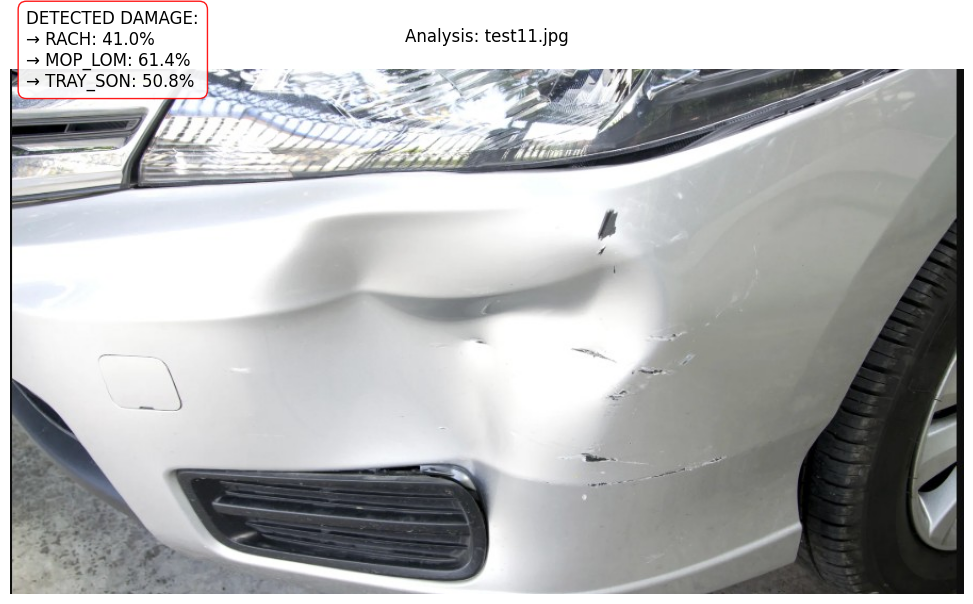


IMAGE: test11.jpg
DAMAGE FOUND:
- RACH: 41.0% confidence
- MOP_LOM: 61.4% confidence
- TRAY_SON: 50.8% confidence


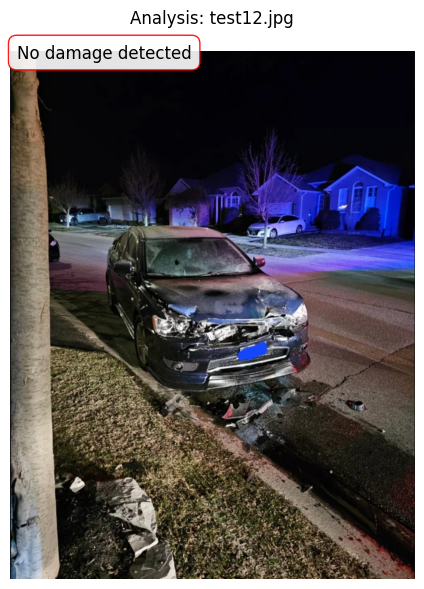


IMAGE: test12.jpg
STATUS: No significant damage detected


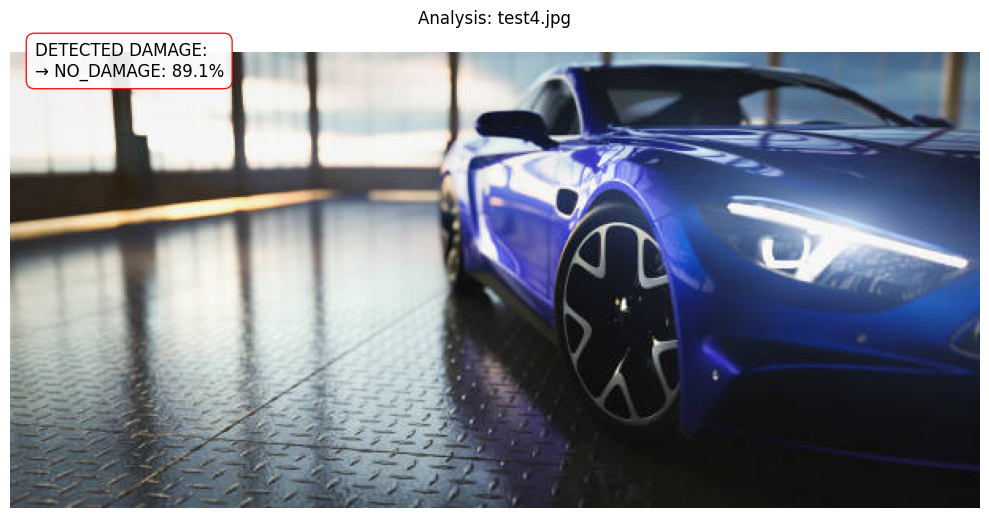


IMAGE: test4.jpg
DAMAGE FOUND:
- NO_DAMAGE: 89.1% confidence


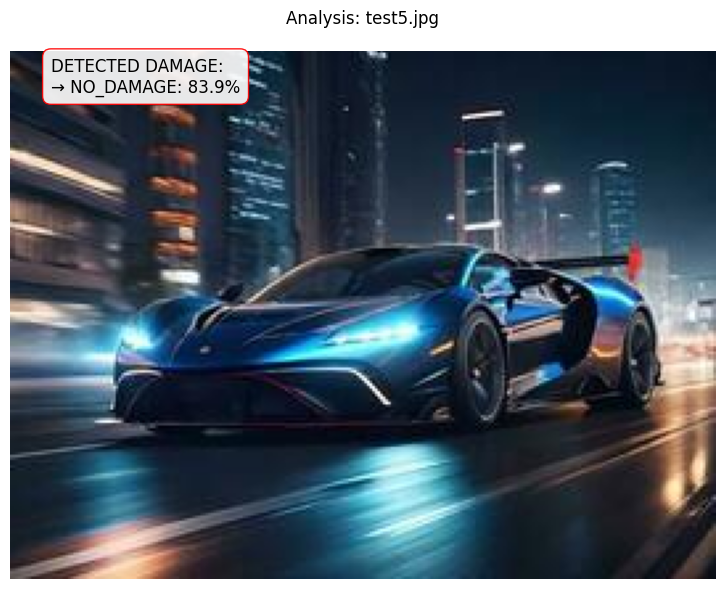


IMAGE: test5.jpg
DAMAGE FOUND:
- NO_DAMAGE: 83.9% confidence


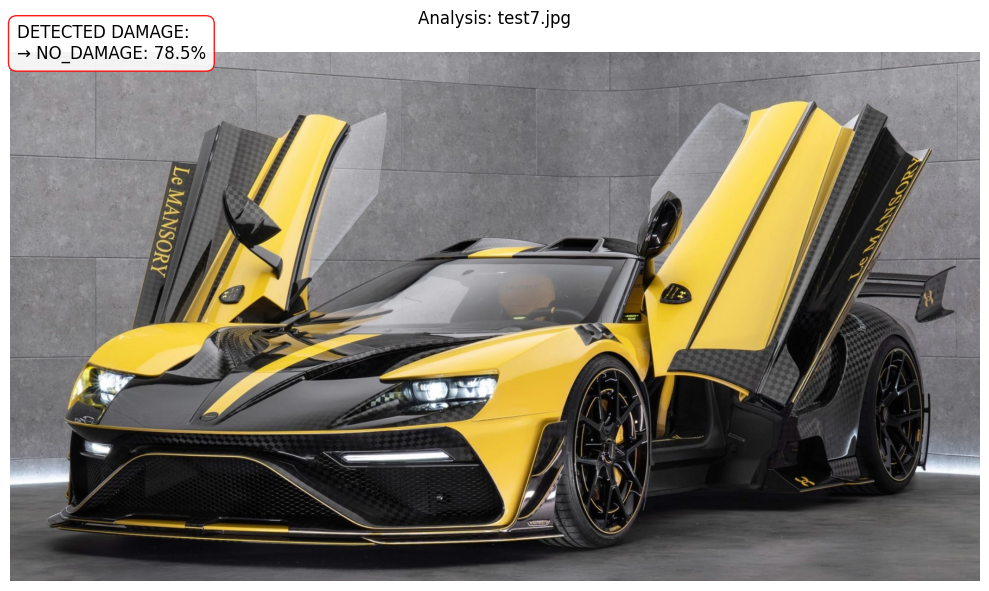


IMAGE: test7.jpg
DAMAGE FOUND:
- NO_DAMAGE: 78.5% confidence


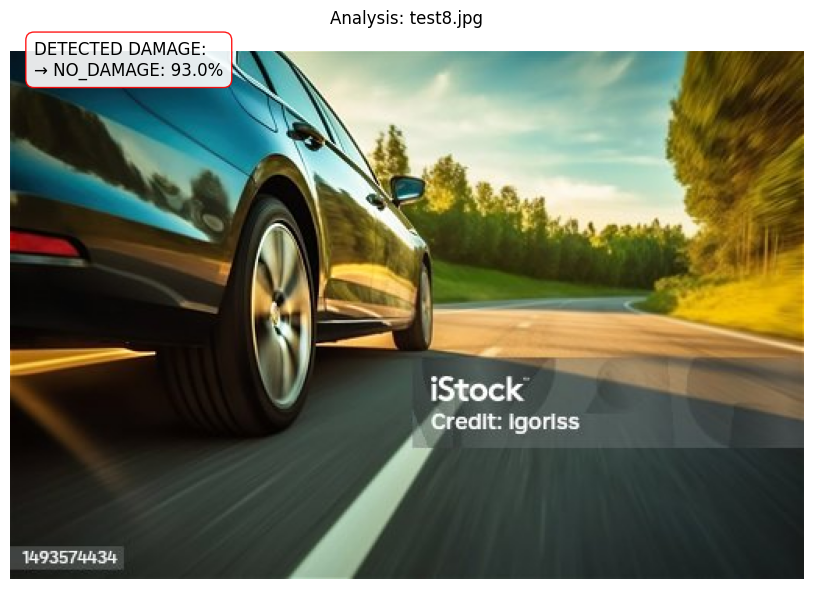


IMAGE: test8.jpg
DAMAGE FOUND:
- NO_DAMAGE: 93.0% confidence


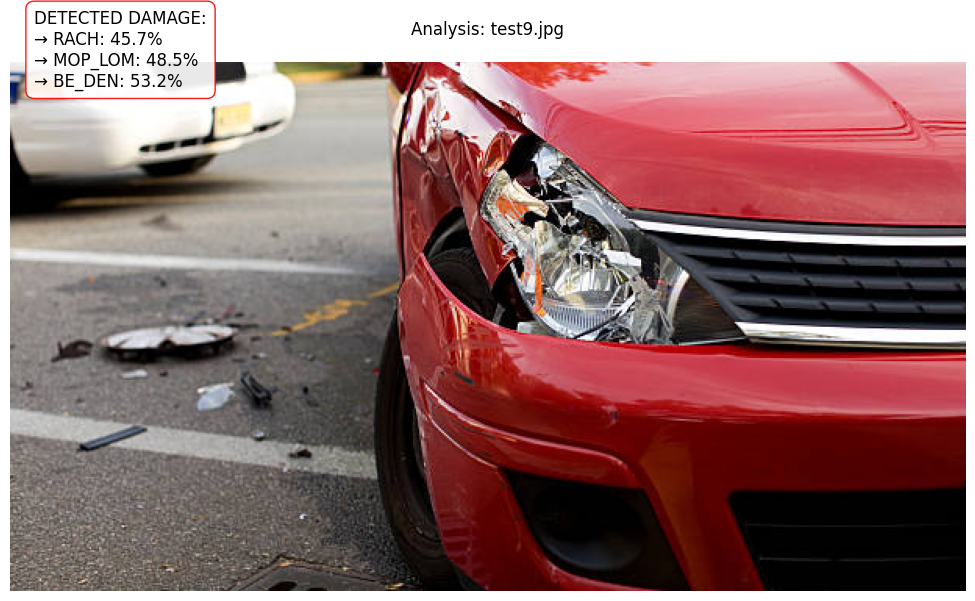


IMAGE: test9.jpg
DAMAGE FOUND:
- RACH: 45.7% confidence
- MOP_LOM: 48.5% confidence
- BE_DEN: 53.2% confidence


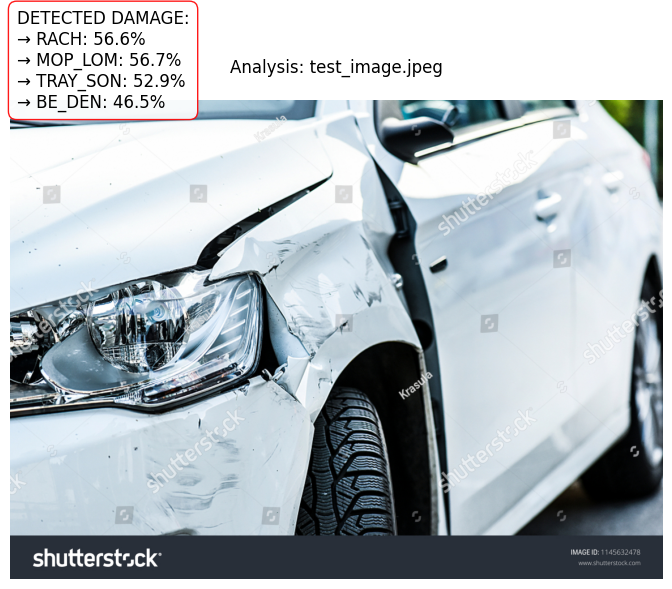


IMAGE: test_image.jpeg
DAMAGE FOUND:
- RACH: 56.6% confidence
- MOP_LOM: 56.7% confidence
- TRAY_SON: 52.9% confidence
- BE_DEN: 46.5% confidence


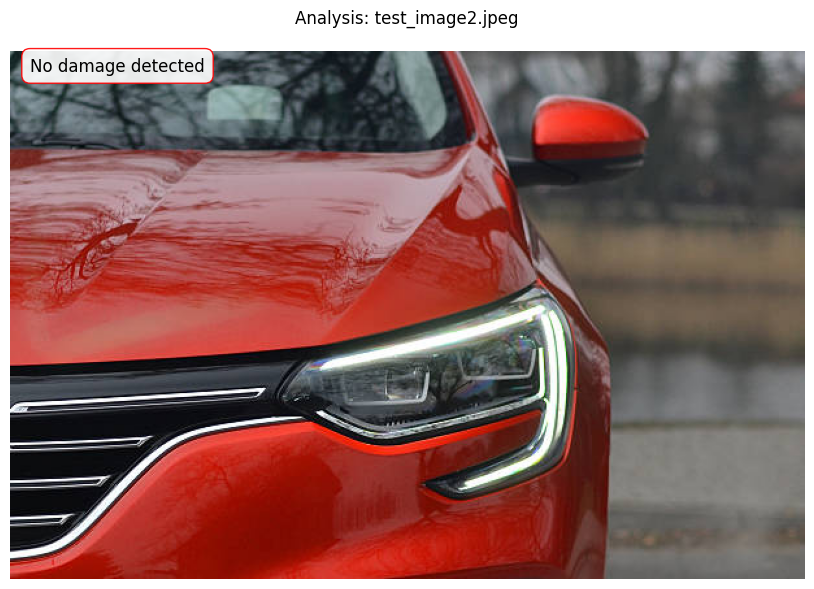


IMAGE: test_image2.jpeg
STATUS: No significant damage detected


In [13]:
import torch
import torch.nn as nn
from torchvision import transforms, models
from PIL import Image
import os
import matplotlib.pyplot as plt
import numpy as np

# --- Configuration ---
CLASSES = ['no_damage', 'mat_bo_phan', 'rach', 'mop_lom', 'tray_son', 'thung', 'vo_kinh', 'be_den']
MODEL_PATH = '/kaggle/working/best_damage_model.pth'
TEST_DIR = '/kaggle/input/predictions/'
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# --- Best tuned thresholds per class (post-validation tuning) ---
# CLASS_THRESHOLDS = [0.25, 0.6, 0.4, 0.45, 0.35, 0.5, 0.45, 0.3]
# CLASS_THRESHOLDS = [0.50, 0.50, 0.43, 0.40, 0.44, 0.43, 0.38, 0.40]
CLASS_THRESHOLDS = best_thresholds
# --- Model Definition (must match training architecture) ---
# class DamageNet(nn.Module):
#     def __init__(self, num_classes):
#         super().__init__()
#         self.base = models.resnet50(weights=None)
#         in_features = self.base.fc.in_features
#         self.base.fc = nn.Sequential(
#             nn.Linear(in_features, 512),
#             nn.ReLU(),
#             nn.Dropout(0.3),
#             nn.Linear(512, num_classes)
#         )

class DamageNet(nn.Module):
    def __init__(self, num_classes):
        super(DamageNet, self).__init__()
        self.base = efficientnet_b2(weights='DEFAULT')  # Load pretrained weights

        # Replace the classifier head
        in_features = self.base.classifier[1].in_features
        self.base.classifier = nn.Sequential(
            nn.Linear(in_features, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes)
        )
        
    def forward(self, x):
        return self.base(x)

# --- Inference Function ---
def predict_test_images(test_dir, transform, thresholds):
    model = DamageNet(len(CLASSES)).to(DEVICE)
    checkpoint = torch.load(MODEL_PATH, map_location=DEVICE)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()
    
    idx_to_class = {v: k for k, v in checkpoint['class_to_idx'].items()}
    
    image_files = [f for f in os.listdir(test_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    
    for img_file in sorted(image_files):
        img_path = os.path.join(test_dir, img_file)
        try:
            img = Image.open(img_path).convert('RGB')
            img_tensor = transform(img).unsqueeze(0).to(DEVICE)
            
            with torch.no_grad():
                outputs = model(img_tensor)
                probs = torch.sigmoid(outputs).cpu().numpy().flatten()
            
            # Apply class-wise thresholds
            predictions = [(idx_to_class[i], float(p)) 
                           for i, p in enumerate(probs) if p >= thresholds[i]]
            
            # Plot with annotation
            plt.figure(figsize=(10, 6))
            plt.imshow(img)
            plt.axis('off')
            if predictions:
                text = "DETECTED DAMAGE:\n" + "\n".join(
                    [f"→ {name.upper()}: {prob:.1%}" for name, prob in predictions])
            else:
                text = "No damage detected"
            
            plt.text(
                15, 15, text,
                fontsize=12,
                bbox=dict(facecolor='white', alpha=0.9, edgecolor='red', boxstyle='round,pad=0.5'),
                color='black'
            )
            plt.title(f"Analysis: {img_file}", pad=20)
            plt.tight_layout()
            plt.show()
            
            # Console report
            print("\n" + "="*60)
            print(f"IMAGE: {img_file}")
            if predictions:
                print("DAMAGE FOUND:")
                for name, prob in predictions:
                    print(f"- {name.upper()}: {prob:.1%} confidence")
            else:
                print("STATUS: No significant damage detected")
            print("="*60)

        except Exception as e:
            print(f"\n⚠️ Error processing {img_file}: {str(e)}")
            continue

# --- Transform (must match training) ---
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# --- Run Inference ---
predict_test_images(TEST_DIR, transform, CLASS_THRESHOLDS)

In [14]:
from sklearn.metrics import classification_report, accuracy_score

# === Reload model ===
# CLASS_THRESHOLDS = [0.25, 0.6, 0.5, 0.62, 0.4, 0.5, 0.45, 0.35]
# CLASS_THRESHOLDS = [0.25, 0.6, 0.4, 0.45, 0.35, 0.5, 0.45, 0.3]
# CLASS_THRESHOLDS = [0.50, 0.50, 0.43, 0.40, 0.44, 0.43, 0.38, 0.40]
CLASS_THRESHOLDS = best_thresholds

model = DamageNet(len(CLASSES)).to(DEVICE)
checkpoint = torch.load(MODEL_PATH, map_location=DEVICE)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

# === Evaluation Loop ===
all_probs = []
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        outputs = model(images)
        probs = torch.sigmoid(outputs).cpu().numpy()
        labels_np = labels.cpu().numpy()
        preds = (probs >= np.array(CLASS_THRESHOLDS)).astype(int)

        all_probs.append(probs)
        all_preds.append(preds)
        all_labels.append(labels_np)

# === Stack everything ===
all_preds = np.vstack(all_preds)
all_labels = np.vstack(all_labels)

# === Classification Report ===
print("\n--- Classification Report with Tuned Thresholds ---")
print(classification_report(all_labels, all_preds, target_names=CLASSES, zero_division=0))

# === Val Accuracy (Exact match) ===
exact_matches = (all_preds == all_labels).all(axis=1).sum()
val_accuracy = exact_matches / len(all_preds)
print(f"\n✅ Val Accuracy (Exact Match): {val_accuracy:.4f}")

/tmp/ipykernel_31/4205498853.py:10: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(MODEL_PATH, map_location=DEVICE)



--- Classification Report with Tuned Thresholds ---
              precision    recall  f1-score   support

   no_damage       0.98      0.99      0.98       300
 mat_bo_phan       0.79      0.73      0.76       402
        rach       0.59      0.82      0.68       659
     mop_lom       0.69      0.66      0.68       750
    tray_son       0.72      0.84      0.77      1142
       thung       0.55      0.63      0.58       318
     vo_kinh       0.94      0.85      0.89       380
      be_den       0.76      0.74      0.75       406

   micro avg       0.72      0.78      0.75      4357
   macro avg       0.75      0.78      0.76      4357
weighted avg       0.73      0.78      0.75      4357
 samples avg       0.77      0.83      0.77      4357


✅ Val Accuracy (Exact Match): 0.4649


In [15]:
# === Class-wise Accuracy ===
print("\n--- Class-wise Accuracy ---")
for i, class_name in enumerate(CLASSES):
    true_labels = all_labels[:, i]
    pred_labels = all_preds[:, i]

    correct = (true_labels == pred_labels).sum()
    total = len(true_labels)

    acc = correct / total if total > 0 else 0.0
    print(f"{class_name:15}: {acc:.4f}")



--- Class-wise Accuracy ---
no_damage      : 0.9962
mat_bo_phan    : 0.9287
rach           : 0.8087
mop_lom        : 0.8197
tray_son       : 0.7851
thung          : 0.8914
vo_kinh        : 0.9703
be_den         : 0.9234
